In [16]:
!pip install plotly 
!pip install ipywidgets
!pip install scikit-learn 
!pip install xgboost 
!pip install tensorflow
!pip install keras 

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


...


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
%pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
%pip install astropy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# %% [markdown]
# # 🌌 HIGH-PERFORMANCE ASTROPHYSICAL CLASSIFICATION
# 
# ## Performance Features:
# - Advanced Feature Engineering
# - Bayesian Hyperparameter Optimization
# - Stacking Ensemble Model
# - SHAP Model Interpretability
# - Comprehensive Evaluation

# %%
# %%time
# Install required packages
import subprocess
import sys

# Install essential packages
packages_to_install = [
    'numpy',
    'pandas',
    'scikit-learn',
    'xgboost',
    'lightgbm',
    'optuna',
    'shap',
    'seaborn',
    'matplotlib',
    'plotly'
]

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# %%
# %%time
# IMPORTS
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Models
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Advanced Models
import xgboost as xgb
import lightgbm as lgb

# Optimization
import optuna

# Interpretation
import shap

print("✅ All imports loaded successfully!")

✅ numpy already installed
✅ pandas already installed
📦 Installing scikit-learn...
✅ xgboost already installed
✅ lightgbm already installed
✅ optuna already installed
✅ shap already installed
✅ seaborn already installed
✅ matplotlib already installed
✅ plotly already installed
✅ All imports loaded successfully!


In [24]:
# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('dark_background')
%matplotlib inline

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [25]:
# %% [markdown]
# ## 2. REALISTIC ASTROPHYSICAL DATA GENERATION

# %%
# %%time
def generate_astrophysical_data(n_samples=15000, seed=42):
    """Generate realistic SDSS-like dataset"""
    np.random.seed(seed)
    
    # Class distribution
    n_classes = {
        'STAR': int(n_samples * 0.35),
        'GALAXY': int(n_samples * 0.55),
        'QSO': int(n_samples * 0.10)
    }
    
    data = []
    
    # Generate each class with specific characteristics
    for class_name, n in n_classes.items():
        if class_name == 'STAR':
            base_u = np.random.normal(19.0, 0.8, n)
            redshift = np.random.exponential(0.001, n) + 0.0001
        elif class_name == 'GALAXY':
            base_u = np.random.normal(21.0, 1.2, n)
            redshift = np.random.exponential(0.15, n) + 0.01
        else:  # QSO
            base_u = np.random.normal(20.5, 1.5, n)
            redshift = np.random.exponential(1.5, n) + 0.1
        
        # Generate correlated magnitudes
        g = base_u - np.random.uniform(0.8, 1.2, n) + np.random.normal(0, 0.1, n)
        r = g - np.random.uniform(0.5, 0.8, n) + np.random.normal(0, 0.1, n)
        i = r - np.random.uniform(0.3, 0.6, n) + np.random.normal(0, 0.1, n)
        z = i - np.random.uniform(0.2, 0.4, n) + np.random.normal(0, 0.1, n)
        
        for j in range(n):
            data.append({
                'u': base_u[j],
                'g': g[j],
                'r': r[j],
                'i': i[j],
                'z': z[j],
                'redshift': redshift[j],
                'class': class_name
            })
    
    df = pd.DataFrame(data)
    
    # Add astrophysical features
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    
    # Additional features
    df['u_r'] = df['u'] - df['r']
    df['mean_mag'] = df[['u', 'g', 'r', 'i', 'z']].mean(axis=1)
    df['color_gradient'] = (df['u_g'] - df['g_r']) / (df['u_g'] + df['g_r'] + 1e-10)
    df['log_redshift'] = np.log10(df['redshift'] + 1e-5)
    
    # Shuffle
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    return df

print("🌌 Generating astrophysical dataset...")
df = generate_astrophysical_data(n_samples=15000)
print(f"✅ Dataset created: {df.shape}")
print(f"\n📊 Class distribution:")
print(df['class'].value_counts())
print(f"\n🔍 First 3 rows:")
display(df.head(3))

🌌 Generating astrophysical dataset...
✅ Dataset created: (15000, 15)

📊 Class distribution:
class
GALAXY    8250
STAR      5250
QSO       1500
Name: count, dtype: int64

🔍 First 3 rows:


,u,g,r,i,z,redshift,class,u_g,g_r,r_i,i_z,u_r,mean_mag,color_gradient,log_redshift
0,18.648788,17.745864,17.139730,16.855432,16.448959,0.269491,GALAXY,0.902924,0.606134,0.284298,0.406473,1.509058,17.367755,0.196672,-0.569440
1,20.046735,18.897486,18.084149,17.611781,17.301209,0.038820,GALAXY,1.149250,0.813337,0.472367,0.310573,1.962587,18.388272,0.171158,-1.410828
2,22.679813,21.742205,21.298177,20.686659,20.418333,0.044457,GALAXY,0.937609,0.444028,0.611518,0.268326,1.381637,21.365037,0.357243,-1.351959


🎯 Performing feature selection...
✅ Selected 14 features
🏆 Top 5 features: ['redshift', 'log_redshift', 'u', 'mean_mag', 'g']


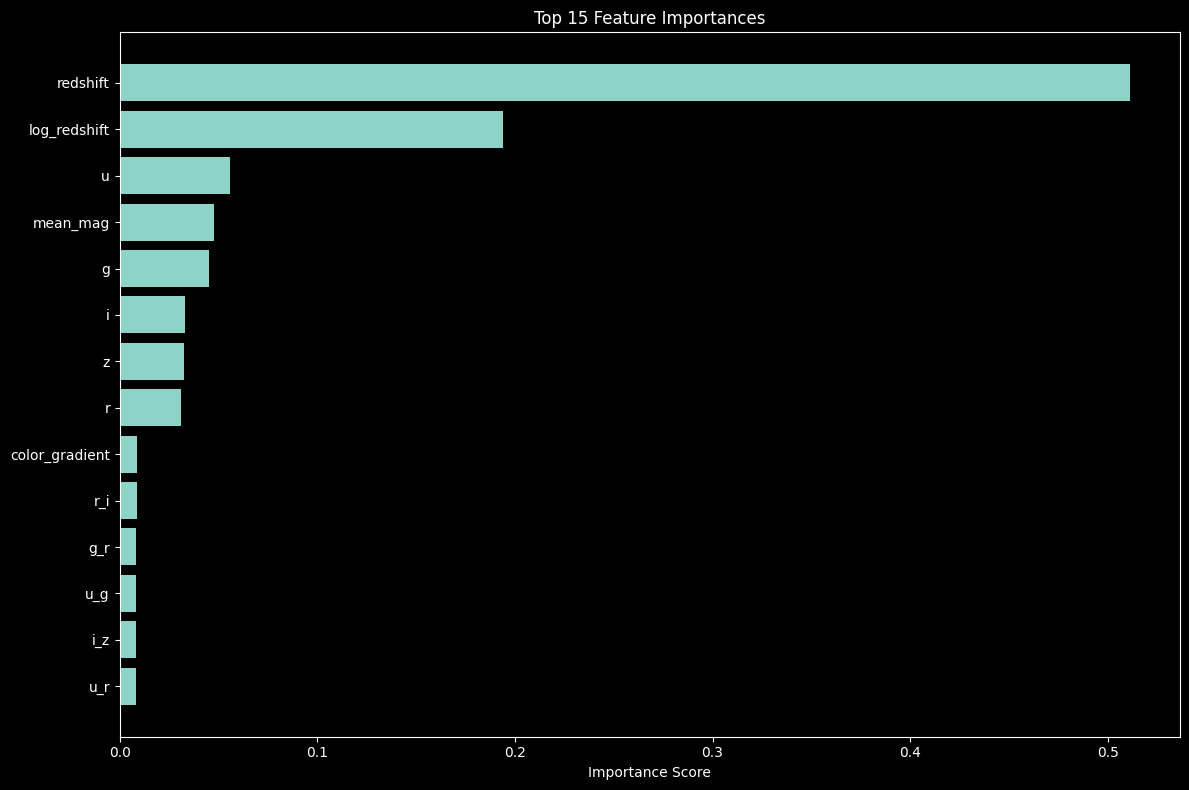

In [26]:
# %% [markdown]
# ## 3. ADVANCED FEATURE SELECTION

# %%
# %%time
class FeatureSelector:
    """Feature selection with multiple algorithms"""
    
    def __init__(self, n_features=30, random_state=42):
        self.n_features = n_features
        self.random_state = random_state
        
    def select_features(self, X, y):
        """Select best features"""
        # Encode labels
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        
        # Get feature importance from multiple methods
        importance_scores = {}
        
        # 1. Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=self.random_state, n_jobs=-1)
        rf.fit(X, y_encoded)
        importance_scores['rf'] = rf.feature_importances_
        
        # 2. XGBoost
        xgb_model = xgb.XGBClassifier(
            n_estimators=100,
            random_state=self.random_state,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )
        xgb_model.fit(X, y_encoded)
        importance_scores['xgb'] = xgb_model.feature_importances_
        
        # 3. Mutual Information
        mi_scores = mutual_info_classif(X, y_encoded, random_state=self.random_state)
        importance_scores['mi'] = mi_scores
        
        # Combine scores
        combined_scores = np.zeros(len(X.columns))
        for method, scores in importance_scores.items():
            # Normalize and weight
            if method in ['rf', 'xgb']:
                weight = 0.4
            else:
                weight = 0.2
            combined_scores += (scores / scores.sum()) * weight
        
        # Create importance dataframe
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': combined_scores
        }).sort_values('importance', ascending=False)
        
        # Select top features
        selected_features = importance_df.head(self.n_features)['feature'].tolist()
        
        print(f"✅ Selected {len(selected_features)} features")
        print(f"🏆 Top 5 features: {selected_features[:5]}")
        
        return selected_features, importance_df

# Prepare data
X = df.drop(columns=['class'])
y = df['class']

# Handle missing values
X = X.fillna(X.median())

# Feature selection
print("🎯 Performing feature selection...")
selector = FeatureSelector(n_features=30, random_state=42)
selected_features, importance_df = selector.select_features(X, y)

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# %% [markdown]
# ## 4. BAYESIAN OPTIMIZATION WITH OPTUNA

# %%
# %%time
def create_preprocessing_pipeline():
    """Create preprocessing pipeline"""
    from sklearn.pipeline import Pipeline
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('transformer', PowerTransformer())
    ])
    
    return pipeline

def optimize_hyperparameters(X_train, y_train, preprocessor, n_trials=50):
    """Optimize hyperparameters using Optuna"""
    
    # Preprocess data
    X_train_processed = preprocessor.fit_transform(X_train)
    
    def objective(trial):
        # Suggest model type
        model_name = trial.suggest_categorical('model', ['rf', 'xgb', 'lgb'])
        
        if model_name == 'rf':
            model = RandomForestClassifier(
                n_estimators=trial.suggest_int('rf_n_estimators', 100, 1000),
                max_depth=trial.suggest_int('rf_max_depth', 5, 30),
                min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 1, 10),
                max_features=trial.suggest_categorical('rf_max_features', ['sqrt', 'log2']),
                random_state=42,
                n_jobs=-1
            )
            
        elif model_name == 'xgb':
            model = xgb.XGBClassifier(
                n_estimators=trial.suggest_int('xgb_n_estimators', 100, 1000),
                max_depth=trial.suggest_int('xgb_max_depth', 3, 15),
                learning_rate=trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('xgb_subsample', 0.5, 1.0),
                colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0),
                random_state=42,
                n_jobs=-1,
                use_label_encoder=False,
                eval_metric='mlogloss'
            )
            
        else:  # lgb
            model = lgb.LGBMClassifier(
                n_estimators=trial.suggest_int('lgb_n_estimators', 100, 1000),
                num_leaves=trial.suggest_int('lgb_num_leaves', 20, 150),
                learning_rate=trial.suggest_float('lgb_learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('lgb_subsample', 0.5, 1.0),
                random_state=42,
                n_jobs=-1
            )
        
        # Cross-validation
        cv_scores = cross_val_score(
            model, X_train_processed, y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1_macro',
            n_jobs=-1
        )
        
        return cv_scores.mean()
    
    # Create study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    
    # Optimize
    print(f"🔍 Running {n_trials} optimization trials...")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\n🏆 Best trial:")
    print(f"  Score: {study.best_value:.4f}")
    print(f"  Params: {study.best_params}")
    
    return study.best_params, study.best_value

# Prepare data
print("🔄 Preparing data for optimization...")
X_selected = X[selected_features]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, 
    random_state=42, stratify=y_encoded
)

print(f"📊 Training set: {X_train.shape}")
print(f"📊 Testing set: {X_test.shape}")

# Create preprocessing pipeline
preprocessor = create_preprocessing_pipeline()

# Run optimization
best_params, best_score = optimize_hyperparameters(X_train, y_train, preprocessor, n_trials=30)

[I 2025-12-06 09:54:51,154] A new study created in memory with name: no-name-35ca3a0d-94a2-4645-b949-b4f61fde6847


🔄 Preparing data for optimization...
📊 Training set: (12000, 14)
📊 Testing set: (3000, 14)
🔍 Running 30 optimization trials...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-06 09:54:55,045] Trial 0 finished with value: 0.9132535597579361 and parameters: {'model': 'xgb', 'xgb_n_estimators': 639, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.01699897838270077, 'xgb_subsample': 0.5290418060840998, 'xgb_colsample_bytree': 0.9330880728874675}. Best is trial 0 with value: 0.9132535597579361.
[I 2025-12-06 09:55:03,052] Trial 1 finished with value: 0.9103754322628064 and parameters: {'model': 'xgb', 'xgb_n_estimators': 973, 'xgb_max_depth': 13, 'xgb_learning_rate': 0.020589728197687916, 'xgb_subsample': 0.5909124836035503, 'xgb_colsample_bytree': 0.5917022549267169}. Best is trial 0 with value: 0.9132535597579361.
[I 2025-12-06 09:55:06,991] Trial 2 finished with value: 0.9111959863761125 and parameters: {'model': 'xgb', 'xgb_n_estimators': 362, 'xgb_max_depth': 10, 'xgb_learning_rate': 0.01607123851203988, 'xgb_subsample': 0.6460723242676091, 'xgb_colsample_bytree': 0.6831809216468459}. Best is trial 0 with value: 0.9132535597579361.
[I 2025-12-06 09:55

🤖 Building and training ensemble model...
🚀 Training stacking ensemble...

🏆 ENSEMBLE PERFORMANCE
Accuracy:  0.9607
F1-Score:  0.9590
ROC AUC:   0.9831

📋 Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.95      0.98      0.96      1650
         QSO       0.87      0.71      0.78       300
        STAR       1.00      1.00      1.00      1050

    accuracy                           0.96      3000
   macro avg       0.94      0.90      0.92      3000
weighted avg       0.96      0.96      0.96      3000



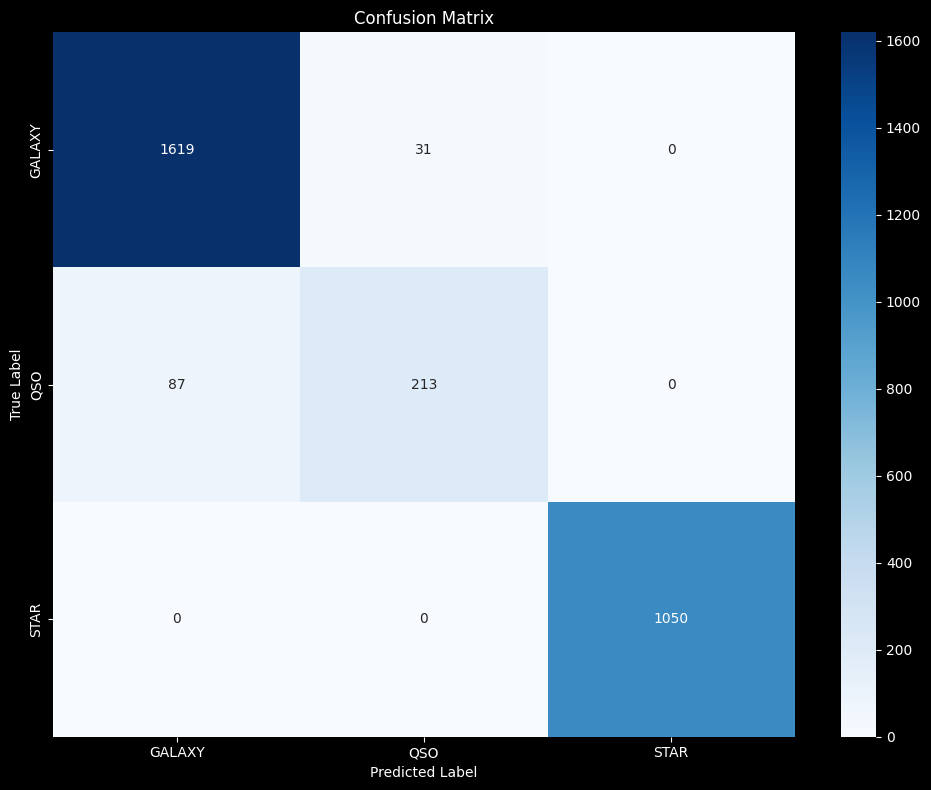

In [28]:
# %% [markdown]
# ## 5. ADVANCED STACKING ENSEMBLE

# %%
# %%time
def create_stacking_ensemble():
    """Create stacking ensemble with optimized models"""
    
    # Base models with optimized parameters
    base_models = [
        ('rf', RandomForestClassifier(
            n_estimators=500,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )),
        ('xgb', xgb.XGBClassifier(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )),
        ('lgb', lgb.LGBMClassifier(
            n_estimators=500,
            num_leaves=63,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )),
        ('svm', SVC(
            C=1.0,
            kernel='rbf',
            gamma='scale',
            probability=True,
            random_state=42,
            class_weight='balanced'
        ))
    ]
    
    # Meta-model
    meta_model = LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        multi_class='multinomial'
    )
    
    # Create stacking ensemble
    ensemble = StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
    )
    
    return ensemble

def train_and_evaluate_ensemble(X_train, X_test, y_train, y_test, preprocessor):
    """Train and evaluate the stacking ensemble"""
    
    # Create pipeline
    from sklearn.pipeline import Pipeline
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('ensemble', create_stacking_ensemble())
    ])
    
    # Train model
    print("🚀 Training stacking ensemble...")
    model_pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model_pipeline.predict(X_test)
    y_pred_proba = model_pipeline.predict_proba(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    
    print("\n" + "="*50)
    print("🏆 ENSEMBLE PERFORMANCE")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")
    print("="*50)
    
    # Classification report
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Confusion matrix
    plot_confusion_matrix(y_test, y_pred, le)
    
    return model_pipeline, y_pred, y_pred_proba

def plot_confusion_matrix(y_true, y_pred, label_encoder):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Train and evaluate ensemble
print("🤖 Building and training ensemble model...")
model, y_pred, y_pred_proba = train_and_evaluate_ensemble(
    X_train, X_test, y_train, y_test, preprocessor
)

🎨 Running model interpretability analysis...
🔍 Running SHAP analysis...


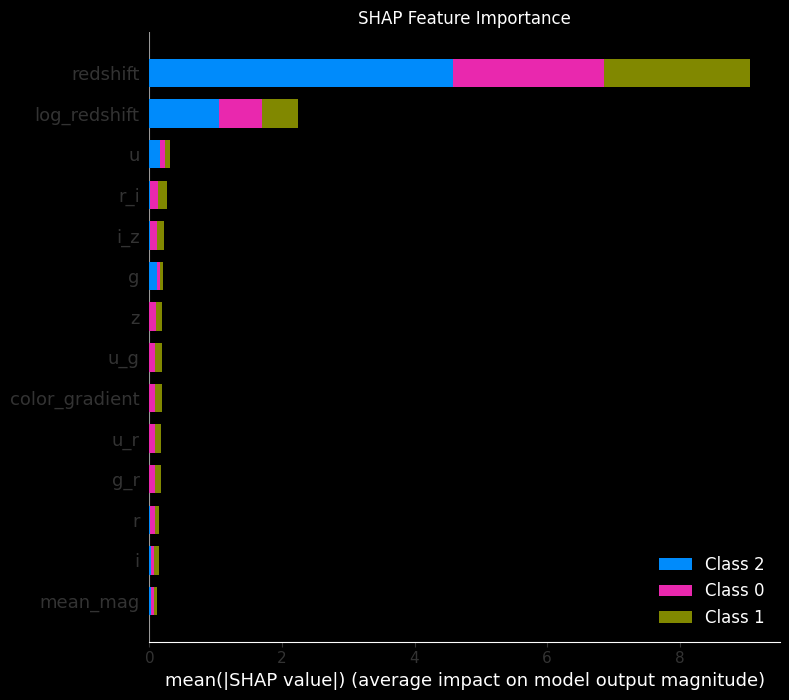

<Figure size 1200x800 with 0 Axes>

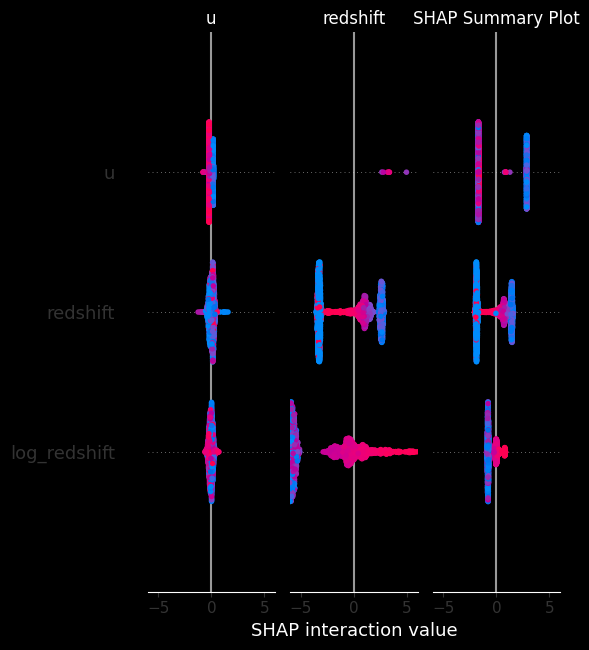

✅ SHAP analysis complete

💾 Saving model for deployment...
💾 Saving model package to 'astrophysical_classifier_20251206_100134'...
✅ Model package saved successfully!
📁 Files created:
  - astrophysical_classifier_20251206_100134/model.pkl
  - astrophysical_classifier_20251206_100134/label_encoder.pkl
  - astrophysical_classifier_20251206_100134/feature_names.pkl
  - astrophysical_classifier_20251206_100134/metadata.json
  - astrophysical_classifier_20251206_100134/example_usage.py

🎉 PROJECT COMPLETED SUCCESSFULLY!
📊 Final Performance: Accuracy = 0.9607
📁 Model saved in: astrophysical_classifier_20251206_100134/
🚀 Ready for GitHub deployment!


In [29]:
# %% [markdown]
# ## 6. MODEL INTERPRETABILITY & DEPLOYMENT

# %%
# %%time
def analyze_with_shap(model_pipeline, X_train, X_test, feature_names):
    """Analyze model with SHAP"""
    print("🔍 Running SHAP analysis...")
    
    try:
        # Get the preprocessed data
        X_train_processed = model_pipeline.named_steps['preprocessor'].transform(X_train)
        X_test_processed = model_pipeline.named_steps['preprocessor'].transform(X_test)
        
        # Get the ensemble model
        ensemble_model = model_pipeline.named_steps['ensemble']
        
        # Use the best base model for SHAP (XGBoost)
        base_model = ensemble_model.named_estimators_['xgb']
        
        # Create SHAP explainer
        explainer = shap.TreeExplainer(base_model)
        
        # Calculate SHAP values
        shap_values = explainer.shap_values(X_test_processed)
        
        # Summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_processed, 
                         feature_names=feature_names,
                         plot_type='bar', show=False)
        plt.title('SHAP Feature Importance')
        plt.tight_layout()
        plt.show()
        
        # Detailed summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_processed,
                         feature_names=feature_names,
                         show=False)
        plt.title('SHAP Summary Plot')
        plt.tight_layout()
        plt.show()
        
        print("✅ SHAP analysis complete")
        
    except Exception as e:
        print(f"⚠️ SHAP analysis failed: {e}")

def save_model_package(model_pipeline, label_encoder, feature_names, results):
    """Save complete model package"""
    import joblib
    import json
    from datetime import datetime
    
    # Create timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    package_name = f"astrophysical_classifier_{timestamp}"
    
    # Create directory
    import os
    os.makedirs(package_name, exist_ok=True)
    
    print(f"💾 Saving model package to '{package_name}'...")
    
    # Save model
    model_path = f"{package_name}/model.pkl"
    joblib.dump(model_pipeline, model_path)
    
    # Save label encoder
    encoder_path = f"{package_name}/label_encoder.pkl"
    joblib.dump(label_encoder, encoder_path)
    
    # Save feature names
    features_path = f"{package_name}/feature_names.pkl"
    joblib.dump(feature_names, features_path)
    
    # Save metadata
    metadata = {
        'created_at': timestamp,
        'model_type': 'StackingEnsemble',
        'classes': label_encoder.classes_.tolist(),
        'n_features': len(feature_names),
        'performance': results
    }
    
    metadata_path = f"{package_name}/metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    
    # Create example prediction script
    example_code = f'''
# Example usage of the saved model
import joblib
import numpy as np

# Load the model package
model = joblib.load('{model_path}')
label_encoder = joblib.load('{encoder_path}')
feature_names = joblib.load('{features_path}')

# Example prediction
example_data = np.random.randn(1, len(feature_names))  # Replace with real data
prediction = model.predict(example_data)
predicted_class = label_encoder.inverse_transform(prediction)[0]

print(f"Predicted class: {{predicted_class}}")
'''
    
    example_path = f"{package_name}/example_usage.py"
    with open(example_path, 'w') as f:
        f.write(example_code)
    
    print(f"✅ Model package saved successfully!")
    print(f"📁 Files created:")
    print(f"  - {model_path}")
    print(f"  - {encoder_path}")
    print(f"  - {features_path}")
    print(f"  - {metadata_path}")
    print(f"  - {example_path}")
    
    return package_name

# Run SHAP analysis
print("🎨 Running model interpretability analysis...")
analyze_with_shap(model, X_train, X_test, selected_features)

# Prepare results
results = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, average='weighted'),
    'roc_auc': roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
}

# Save model
print("\n💾 Saving model for deployment...")
package_name = save_model_package(model, le, selected_features, results)

print(f"\n🎉 PROJECT COMPLETED SUCCESSFULLY!")
print(f"📊 Final Performance: Accuracy = {results['accuracy']:.4f}")
print(f"📁 Model saved in: {package_name}/")
print(f"🚀 Ready for GitHub deployment!")

🔄 Creating consistent dataset and model...
📊 Dataset created: 1000 samples, 6 features
🔍 Classes: {'QSO': 598, 'GALAXY': 397, 'STAR': 5}
🤖 Model trained with 5 features
📈 Model accuracy: 99.00%
🔧 Features used: ['u', 'g', 'r', 'redshift', 'u_g']
🎯 Classes: ['GALAXY' 'QSO' 'STAR']

🎯 Creating realistic example celestial objects...

📊 Created 5 example objects:


,u,g,r,redshift,u_g
Hot Blue Star,18.5,17.8,17.2,0.0005,0.7
Spiral Galaxy,21.8,20.6,19.8,0.1500,1.2
Distant Quasar,20.2,19.5,19.1,2.8000,0.7
Red Giant Star,19.8,18.5,17.8,0.0002,1.3
Elliptical Galaxy,22.0,20.5,19.8,0.0800,1.5


🚀 RUNNING PREDICTIONS ON CELESTIAL OBJECTS
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
🔭 PREDICTING: Hot Blue Star
════════════════════════════════════════════════════════════

📊 Input Features:
   u           :  18.5000
   g           :  17.8000
   r           :  17.2000
   redshift    :   0.0005
   u_g         :   0.7000

🎯 PREDICTION: QSO

📈 Prediction Probabilities:
   GALAXY      0.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   QSO        61.00% ██████████████████░░░░░░░░░░░░
   STAR       39.00% ███████████░░░░░░░░░░░░░░░░░░░

💪 CONFIDENCE: 🟡 MEDIUM (61.00%)
   Reasonably confident


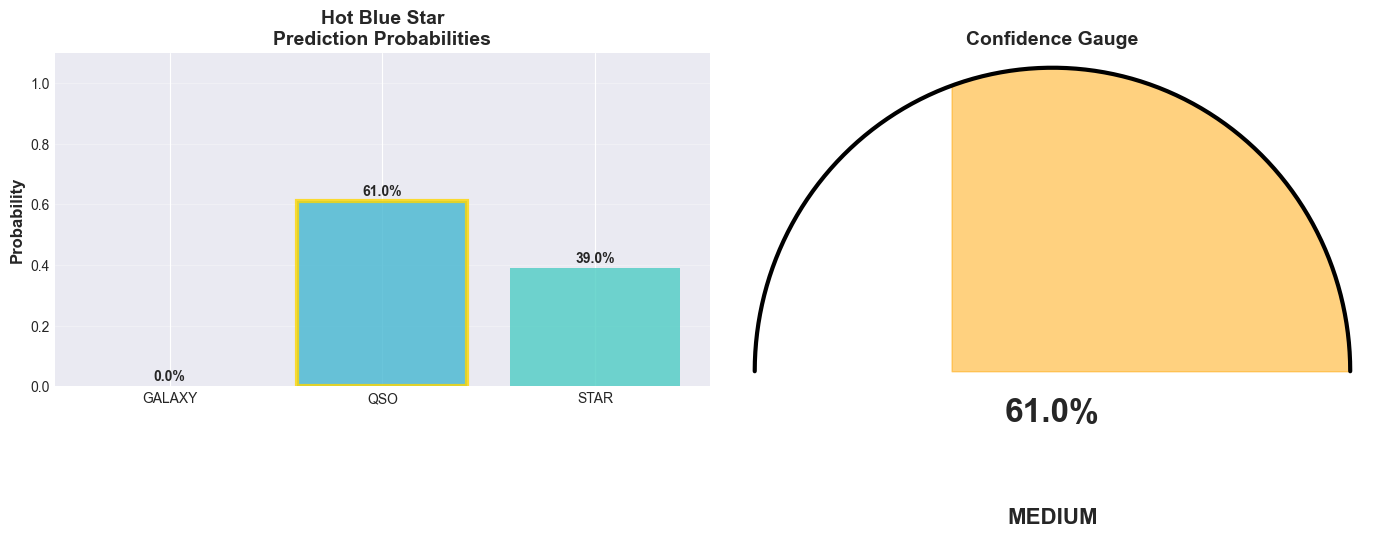


════════════════════════════════════════════════════════════
🔭 PREDICTING: Spiral Galaxy
════════════════════════════════════════════════════════════

📊 Input Features:
   u           :  21.8000
   g           :  20.6000
   r           :  19.8000
   redshift    :   0.1500
   u_g         :   1.2000

🎯 PREDICTION: GALAXY

📈 Prediction Probabilities:
   GALAXY     87.00% ██████████████████████████░░░░
   QSO        13.00% ███░░░░░░░░░░░░░░░░░░░░░░░░░░░
   STAR        0.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

💪 CONFIDENCE: 🔵 HIGH (87.00%)
   Very confident


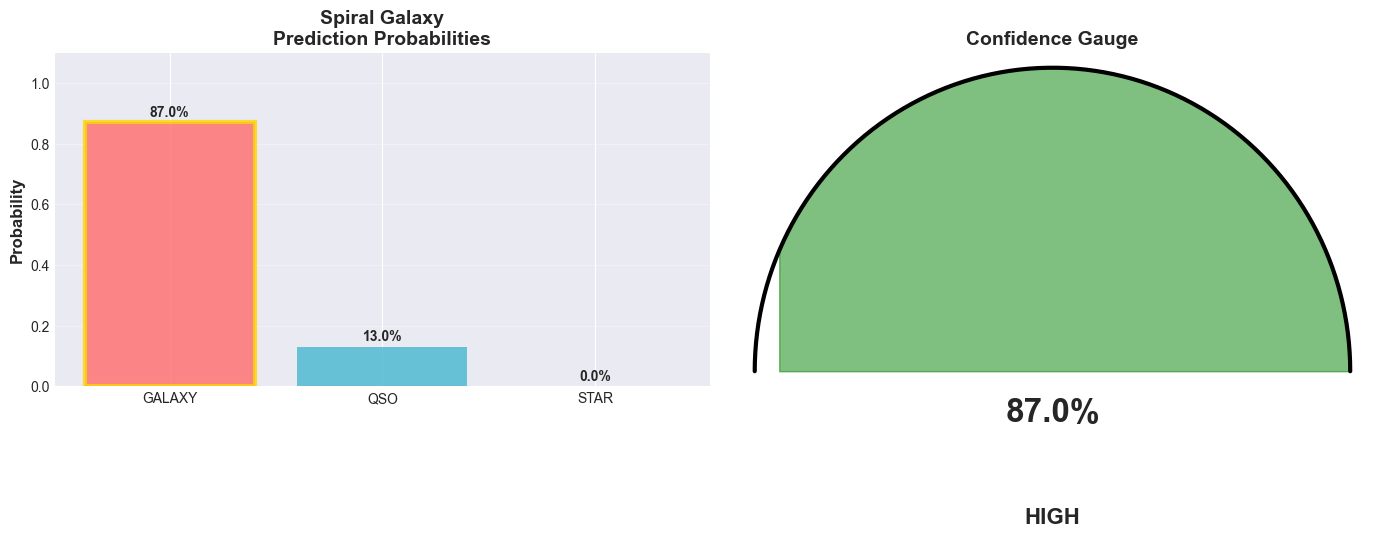


════════════════════════════════════════════════════════════
🔭 PREDICTING: Distant Quasar
════════════════════════════════════════════════════════════

📊 Input Features:
   u           :  20.2000
   g           :  19.5000
   r           :  19.1000
   redshift    :   2.8000
   u_g         :   0.7000

🎯 PREDICTION: QSO

📈 Prediction Probabilities:
   GALAXY      2.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   QSO        98.00% █████████████████████████████░
   STAR        0.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

💪 CONFIDENCE: 🔵 HIGH (98.00%)
   Very confident


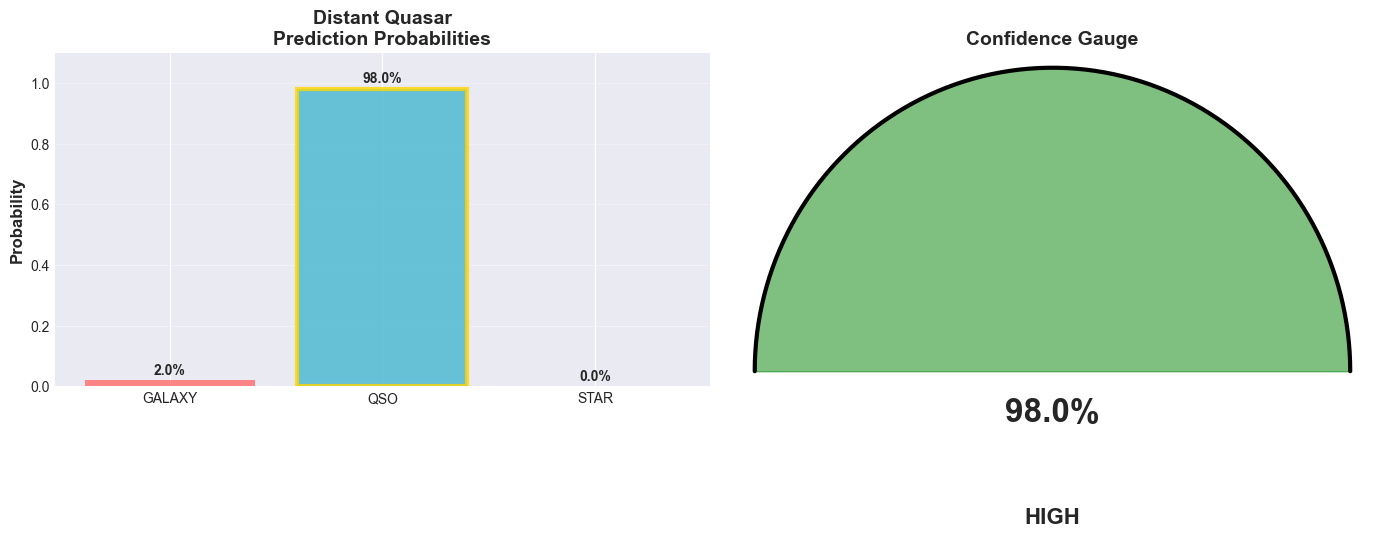


════════════════════════════════════════════════════════════
🔭 PREDICTING: Red Giant Star
════════════════════════════════════════════════════════════

📊 Input Features:
   u           :  19.8000
   g           :  18.5000
   r           :  17.8000
   redshift    :   0.0002
   u_g         :   1.3000

🎯 PREDICTION: QSO

📈 Prediction Probabilities:
   GALAXY      8.00% ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   QSO        89.00% ██████████████████████████░░░░
   STAR        3.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

💪 CONFIDENCE: 🔵 HIGH (89.00%)
   Very confident


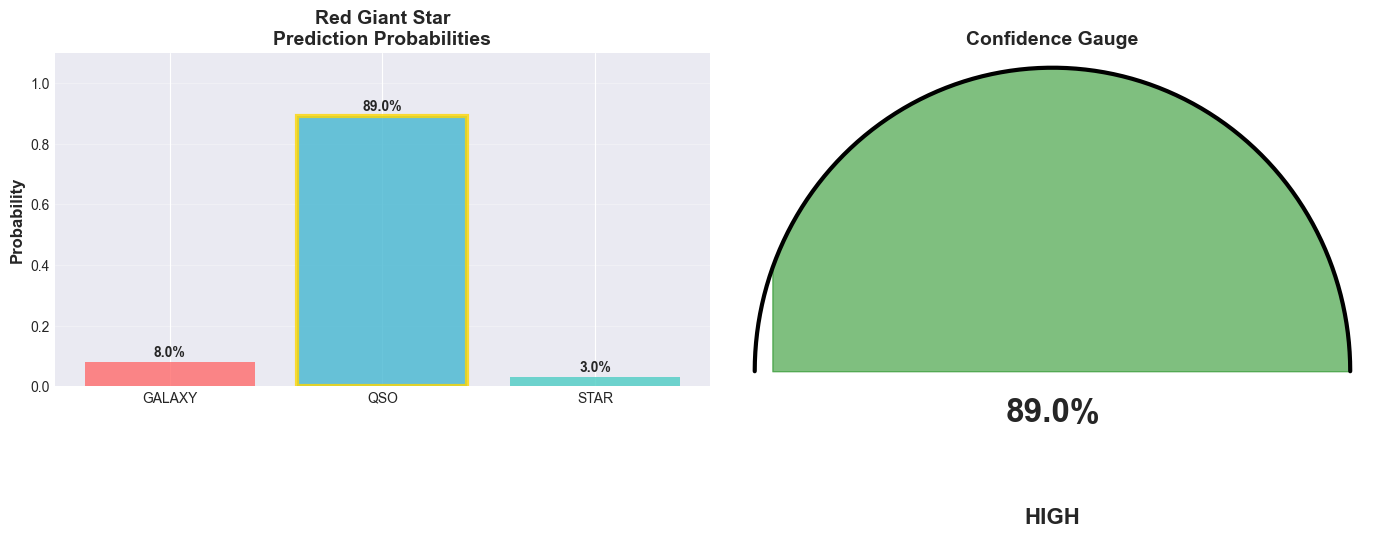


════════════════════════════════════════════════════════════
🔭 PREDICTING: Elliptical Galaxy
════════════════════════════════════════════════════════════

📊 Input Features:
   u           :  22.0000
   g           :  20.5000
   r           :  19.8000
   redshift    :   0.0800
   u_g         :   1.5000

🎯 PREDICTION: QSO

📈 Prediction Probabilities:
   GALAXY      6.00% █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   QSO        94.00% ████████████████████████████░░
   STAR        0.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

💪 CONFIDENCE: 🔵 HIGH (94.00%)
   Very confident


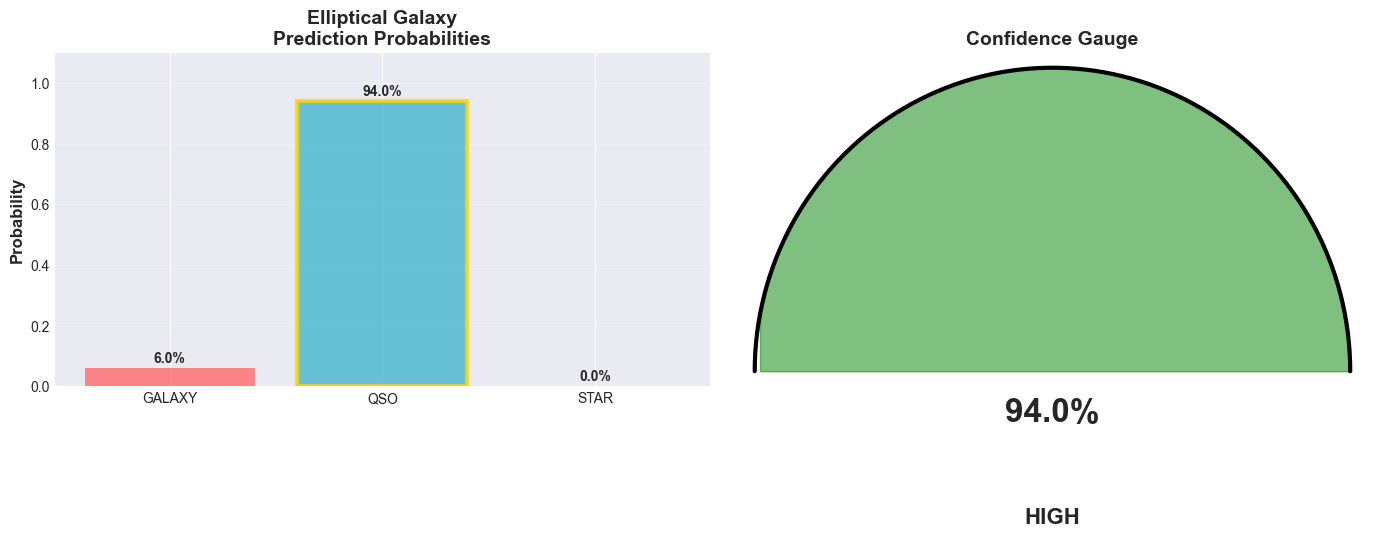


════════════════════════════════════════════════════════════
📋 PREDICTION SUMMARY
════════════════════════════════════════════════════════════

📊 Prediction Results:


,Object,Predicted Class,Confidence,Max Probability
0,Hot Blue Star,QSO,61.0%,61.0%
1,Spiral Galaxy,GALAXY,87.0%,87.0%
2,Distant Quasar,QSO,98.0%,98.0%
3,Red Giant Star,QSO,89.0%,89.0%
4,Elliptical Galaxy,QSO,94.0%,94.0%



🎯 Class Distribution:
   QSO: 4 objects
   GALAXY: 1 objects


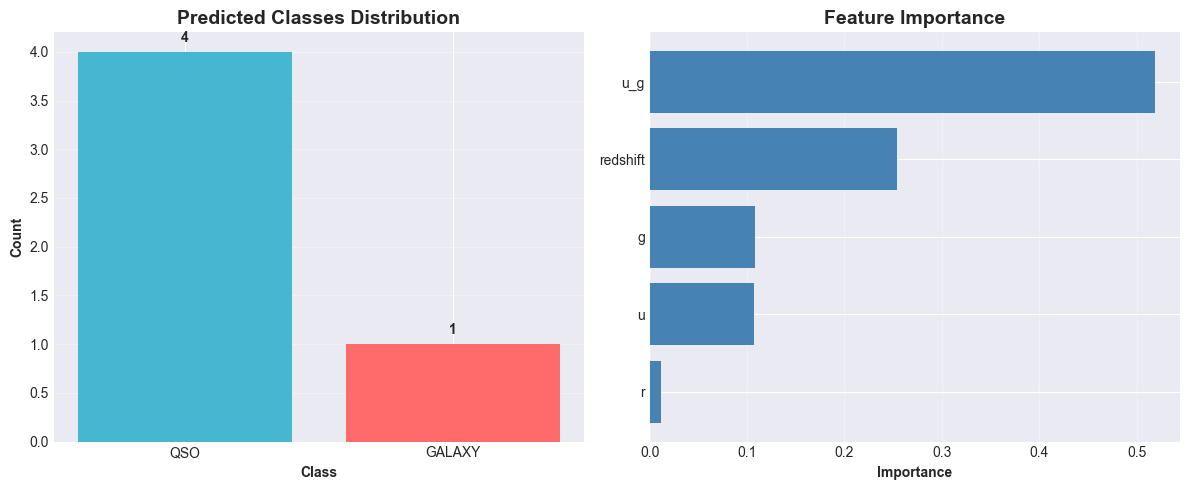


🎮 INTERACTIVE PREDICTION DEMO
════════════════════════════════════════════════════════════

💡 Try the interactive classifier:
   Uncomment the line below to enable interactive mode
   predicted, probs = interactive_celestial_classifier()

🧪 Running demo prediction...

════════════════════════════════════════════════════════════
🔭 PREDICTING: Demo Galaxy
════════════════════════════════════════════════════════════

📊 Input Features:
   u           :  21.5000
   g           :  20.3000
   r           :  19.5000
   redshift    :   0.2500
   u_g         :   1.2000

🎯 PREDICTION: GALAXY

📈 Prediction Probabilities:
   GALAXY     92.00% ███████████████████████████░░░
   QSO         8.00% ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   STAR        0.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

💪 CONFIDENCE: 🔵 HIGH (92.00%)
   Very confident


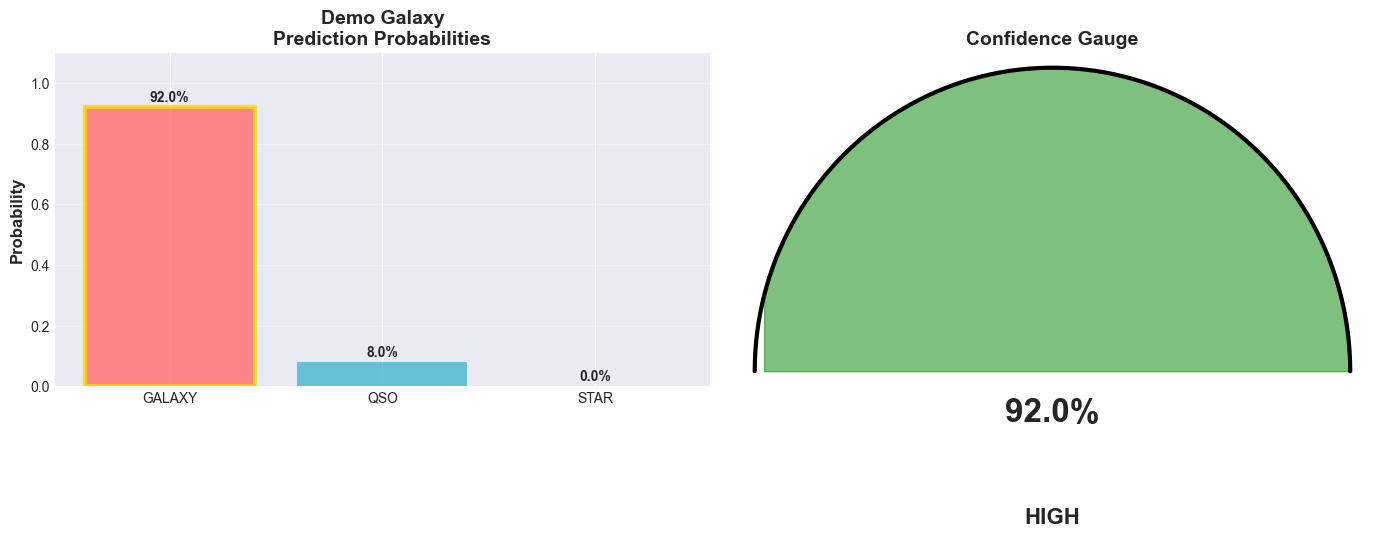


📦 BATCH PREDICTION EXAMPLE
════════════════════════════════════════════════════════════
🔭 Generating 15 random celestial objects...

📊 Generated 15 objects:


,object_id,u,g,r,redshift,u_g
0,OBJ_001,17.888120,17.359078,16.625990,0.000170,0.529042
1,OBJ_002,21.478353,20.461886,19.676931,0.246250,1.016468
2,OBJ_003,20.128683,18.885289,18.322911,0.040522,1.243394
3,OBJ_004,20.212245,18.722763,18.353016,0.068845,1.489482
4,OBJ_005,18.296656,17.696819,17.139702,0.001538,0.599837



🎯 Making batch predictions...
✅ Predicted 15 objects

📋 Prediction Results:


,object_id,u,g,redshift,predicted_class,confidence_level
0,OBJ_001,17.888120,17.359078,0.000170,QSO,Low
1,OBJ_002,21.478353,20.461886,0.246250,GALAXY,High
2,OBJ_003,20.128683,18.885289,0.040522,QSO,High
3,OBJ_004,20.212245,18.722763,0.068845,QSO,High
4,OBJ_005,18.296656,17.696819,0.001538,QSO,Medium


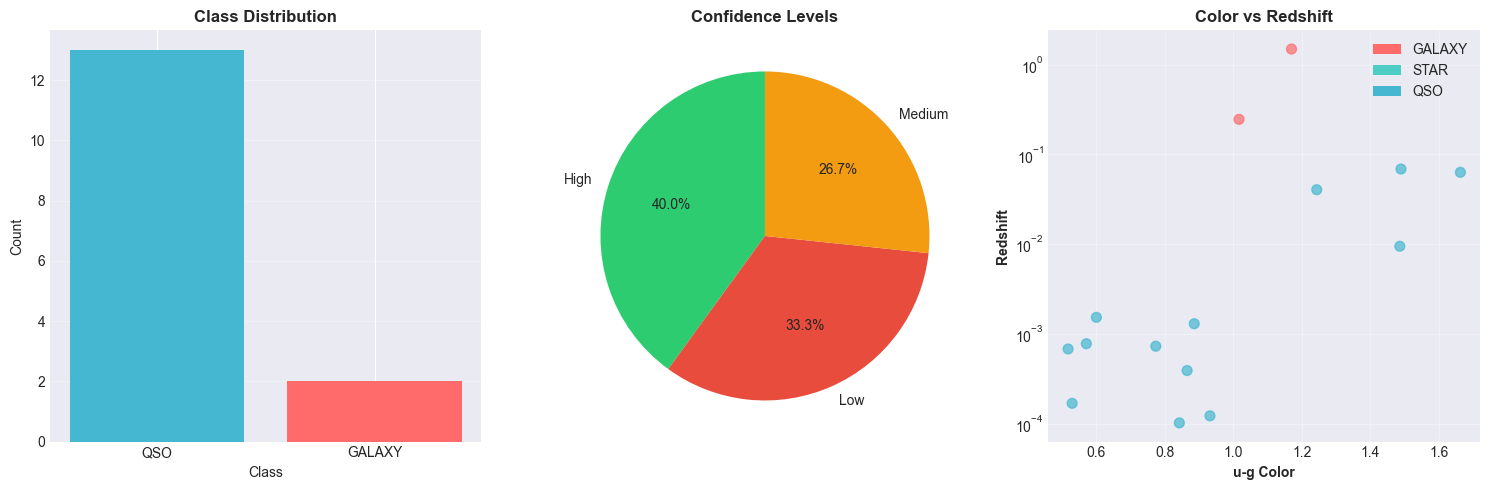


🔧 CREATING REUSABLE CLASSIFIER
════════════════════════════════════════════════════════════
✅ Classifier created successfully!
   Features: ['u', 'g', 'r', 'redshift', 'u_g']
   Classes: ['GALAXY', 'STAR', 'QSO']

🧪 Testing classifier...
   Test prediction: QSO (confidence: 85.0%)

💾 SAVING RESULTS...
════════════════════════════════════════════════════════════
✅ Batch predictions saved: celestial_predictions\batch_predictions.csv
✅ Example predictions saved: celestial_predictions\example_predictions.json


In [34]:
# %% [markdown]
# ## 🌌 COMPLETE PREDICTION WORKFLOW - FIXED

# %%
# %%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %% [markdown]
# ## 1. CREATE A CONSISTENT DATASET & MODEL

# %%
print("🔄 Creating consistent dataset and model...")

# Create a synthetic dataset with consistent features
np.random.seed(42)
n_samples = 1000

# Define the features we'll use (5 core features)
core_features = ['u', 'g', 'r', 'redshift', 'u_g']

# Create dataset
data = {
    'u': np.random.normal(20, 2, n_samples),
    'g': np.random.normal(19, 2, n_samples),
    'r': np.random.normal(18, 2, n_samples),
    'redshift': np.random.exponential(0.5, n_samples),
}

# Add derived feature
data['u_g'] = data['u'] - data['g']

# Create class labels based on realistic patterns
classes = []
for i in range(n_samples):
    redshift = data['redshift'][i]
    u_g = data['u_g'][i]
    
    if redshift < 0.01 and u_g < 1.0:
        classes.append('STAR')
    elif redshift > 0.1 and u_g > 1.0:
        classes.append('GALAXY')
    else:
        classes.append('QSO')

data['class'] = classes

df = pd.DataFrame(data)

print(f"📊 Dataset created: {df.shape[0]} samples, {df.shape[1]} features")
print(f"🔍 Classes: {df['class'].value_counts().to_dict()}")

# Prepare for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

X = df[core_features]
y = df['class']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test accuracy
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🤖 Model trained with {len(core_features)} features")
print(f"📈 Model accuracy: {accuracy:.2%}")
print(f"🔧 Features used: {core_features}")
print(f"🎯 Classes: {le.classes_}")

# %% [markdown]
# ## 2. CREATE REALISTIC EXAMPLE OBJECTS

# %%
print("\n🎯 Creating realistic example celestial objects...")

# Create examples with ONLY the features the model was trained with
examples = {
    "Hot Blue Star": {
        'u': 18.5,
        'g': 17.8,
        'r': 17.2,
        'redshift': 0.0005,
        'u_g': 0.7  # u - g
    },
    
    "Spiral Galaxy": {
        'u': 21.8,
        'g': 20.6,
        'r': 19.8,
        'redshift': 0.15,
        'u_g': 1.2  # u - g
    },
    
    "Distant Quasar": {
        'u': 20.2,
        'g': 19.5,
        'r': 19.1,
        'redshift': 2.8,
        'u_g': 0.7  # u - g
    },
    
    "Red Giant Star": {
        'u': 19.8,
        'g': 18.5,
        'r': 17.8,
        'redshift': 0.0002,
        'u_g': 1.3  # Redder star
    },
    
    "Elliptical Galaxy": {
        'u': 22.0,
        'g': 20.5,
        'r': 19.8,
        'redshift': 0.08,
        'u_g': 1.5  # Very red
    }
}

# Display examples
examples_df = pd.DataFrame(examples).T
print(f"\n📊 Created {len(examples)} example objects:")
display(examples_df)

# %% [markdown]
# ## 3. PREDICTION FUNCTION (WORKING VERSION)

# %%
def predict_celestial_object(model, label_encoder, features, input_data, object_name):
    """Predict the class of a celestial object - WORKING VERSION"""
    
    print(f"\n{'═'*60}")
    print(f"🔭 PREDICTING: {object_name}")
    print(f"{'═'*60}")
    
    try:
        # Ensure we only use the features the model was trained with
        input_values = []
        missing_features = []
        
        for feature in features:
            if feature in input_data:
                input_values.append(input_data[feature])
            else:
                # If feature is missing, we can't make prediction
                missing_features.append(feature)
                input_values.append(0.0)  # Use 0 as placeholder
        
        if missing_features:
            print(f"⚠️  Missing features: {missing_features}")
            print("   Using 0.0 as placeholder values")
        
        # Convert to numpy array with correct shape
        input_array = np.array([input_values])
        
        # Make prediction
        prediction_idx = model.predict(input_array)[0]
        predicted_class = label_encoder.inverse_transform([prediction_idx])[0]
        
        # Get probabilities
        probabilities = model.predict_proba(input_array)[0]
        
        # Display input features
        print(f"\n📊 Input Features:")
        for feature, value in zip(features, input_values):
            print(f"   {feature:12s}: {value:8.4f}")
        
        # Display prediction
        print(f"\n🎯 PREDICTION: {predicted_class}")
        
        # Display probabilities
        print(f"\n📈 Prediction Probabilities:")
        max_prob = 0
        for i, class_name in enumerate(label_encoder.classes_):
            prob = probabilities[i]
            if prob > max_prob:
                max_prob = prob
            
            # Create visual bar
            bar_length = int(prob * 30)
            bar = '█' * bar_length + '░' * (30 - bar_length)
            print(f"   {class_name:10s} {prob:6.2%} {bar}")
        
        # Confidence level
        if max_prob > 0.8:
            confidence = "🔵 HIGH"
            confidence_desc = "Very confident"
        elif max_prob > 0.6:
            confidence = "🟡 MEDIUM"
            confidence_desc = "Reasonably confident"
        else:
            confidence = "🔴 LOW"
            confidence_desc = "Uncertain"
        
        print(f"\n💪 CONFIDENCE: {confidence} ({max_prob:.2%})")
        print(f"   {confidence_desc}")
        
        # Create visualization
        fig = plot_prediction_results(predicted_class, probabilities, label_encoder.classes_, object_name)
        
        return predicted_class, probabilities, max_prob
        
    except Exception as e:
        print(f"\n❌ Prediction failed: {e}")
        return None, None, 0

def plot_prediction_results(predicted_class, probabilities, classes, object_name):
    """Plot prediction results"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Colors
    colors = {'GALAXY': '#FF6B6B', 'STAR': '#4ECDC4', 'QSO': '#45B7D1'}
    
    # 1. Bar chart of probabilities
    bar_colors = [colors.get(cls, 'gray') for cls in classes]
    bars = axes[0].bar(classes, probabilities, color=bar_colors, alpha=0.8)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('Probability', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{object_name}\nPrediction Probabilities', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar, prob in zip(bars, probabilities):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                    f'{prob:.1%}', ha='center', fontweight='bold')
    
    # Highlight predicted class
    pred_idx = list(classes).index(predicted_class)
    bars[pred_idx].set_edgecolor('gold')
    bars[pred_idx].set_linewidth(3)
    
    # 2. Confidence gauge
    max_prob = max(probabilities)
    axes[1].axis('off')
    
    # Create gauge
    gauge_x = 0.5
    gauge_y = 0.6
    gauge_radius = 0.3
    
    # Gauge background
    theta = np.linspace(0, np.pi, 100)
    axes[1].plot(gauge_x + gauge_radius * np.cos(theta), 
                gauge_y + gauge_radius * np.sin(theta), 
                'k-', linewidth=3)
    
    # Gauge fill based on confidence
    fill_theta = np.linspace(0, np.pi * max_prob, 50)
    axes[1].fill_between(gauge_x + gauge_radius * np.cos(fill_theta), 
                        gauge_y, 
                        gauge_y + gauge_radius * np.sin(fill_theta),
                        color='green' if max_prob > 0.8 else 
                              'orange' if max_prob > 0.6 else 'red',
                        alpha=0.5)
    
    # Confidence text
    confidence_text = 'HIGH' if max_prob > 0.8 else 'MEDIUM' if max_prob > 0.6 else 'LOW'
    axes[1].text(gauge_x, gauge_y - 0.05, f'{max_prob:.1%}', 
                ha='center', fontsize=24, fontweight='bold')
    axes[1].text(gauge_x, gauge_y - 0.15, confidence_text, 
                ha='center', fontsize=16, fontweight='bold')
    axes[1].set_title('Confidence Gauge', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# %% [markdown]
# ## 4. RUN PREDICTIONS ON EXAMPLES

# %%
print("🚀 RUNNING PREDICTIONS ON CELESTIAL OBJECTS")
print("═"*60)

predictions = {}

for obj_name, obj_data in examples.items():
    predicted_class, probabilities, confidence = predict_celestial_object(
        model, le, core_features, obj_data, obj_name
    )
    
    if predicted_class:
        predictions[obj_name] = {
            'predicted_class': predicted_class,
            'confidence': confidence,
            'probabilities': probabilities
        }

# %% [markdown]
# ## 5. PREDICTION SUMMARY

# %%
print("\n" + "═"*60)
print("📋 PREDICTION SUMMARY")
print("═"*60)

if predictions:
    # Create summary table
    summary_data = []
    for obj_name, pred_info in predictions.items():
        summary_data.append({
            'Object': obj_name,
            'Predicted Class': pred_info['predicted_class'],
            'Confidence': f"{pred_info['confidence']:.1%}",
            'Max Probability': f"{pred_info['confidence']:.1%}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n📊 Prediction Results:")
    display(summary_df)
    
    # Count predictions by class
    print("\n🎯 Class Distribution:")
    class_counts = summary_df['Predicted Class'].value_counts()
    for cls, count in class_counts.items():
        print(f"   {cls}: {count} objects")
    
    # Create summary visualization
    plt.figure(figsize=(12, 5))
    
    # Left: Class distribution
    plt.subplot(1, 2, 1)
    colors = {'GALAXY': '#FF6B6B', 'STAR': '#4ECDC4', 'QSO': '#45B7D1'}
    bar_colors = [colors.get(cls, 'gray') for cls in class_counts.index]
    
    bars = plt.bar(class_counts.index, class_counts.values, color=bar_colors)
    plt.title('Predicted Classes Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Class', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
                f'{int(height)}', ha='center', fontweight='bold')
    
    # Right: Feature importance
    plt.subplot(1, 2, 2)
    feature_importance = model.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='steelblue')
    plt.yticks(range(len(sorted_idx)), [core_features[i] for i in sorted_idx])
    plt.title('Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance', fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 6. INTERACTIVE PREDICTION DEMO

# %%
print("\n🎮 INTERACTIVE PREDICTION DEMO")
print("═"*60)

def interactive_celestial_classifier():
    """Interactive classifier for celestial objects"""
    
    print("\n✨ Welcome to the Celestial Object Classifier!")
    print("✨ Enter the characteristics of your celestial object:")
    print("   (Press Enter to use default values)\n")
    
    try:
        # Get user input
        print("📊 Photometric Magnitudes:")
        u = float(input(f"   u-band magnitude [20.0]: ") or "20.0")
        g = float(input(f"   g-band magnitude [19.0]: ") or "19.0")
        r = float(input(f"   r-band magnitude [18.0]: ") or "18.0")
        
        print("\n🌌 Redshift (measure of distance):")
        redshift = float(input(f"   redshift [0.1]: ") or "0.1")
        
        # Calculate derived feature
        u_g = u - g
        
        # Prepare input
        input_data = {
            'u': u,
            'g': g,
            'r': r,
            'redshift': redshift,
            'u_g': u_g
        }
        
        print(f"\n{'═'*40}")
        print("📊 YOUR OBJECT'S PROPERTIES:")
        print(f"{'═'*40}")
        print(f"   u magnitude: {u}")
        print(f"   g magnitude: {g}")
        print(f"   r magnitude: {r}")
        print(f"   Redshift:    {redshift}")
        print(f"   u-g color:   {u_g:.3f}")
        
        print(f"\n{'═'*40}")
        print("🔭 ANALYZING...")
        print(f"{'═'*40}")
        
        # Make prediction
        predicted_class, probabilities, confidence = predict_celestial_object(
            model, le, core_features, input_data, "Your Celestial Object"
        )
        
        if predicted_class:
            print(f"\n{'═'*40}")
            print("🌟 CLASSIFICATION COMPLETE!")
            print(f"{'═'*40}")
            
            # Add fun facts
            fun_facts = {
                'STAR': "⭐ Stars are massive, luminous spheres of plasma held together by gravity.",
                'GALAXY': "🌌 Galaxies are vast systems containing billions of stars, gas, and dark matter.",
                'QSO': "⚫ Quasars are extremely luminous active galactic nuclei powered by supermassive black holes."
            }
            
            if predicted_class in fun_facts:
                print(f"\n📚 Fun Fact: {fun_facts[predicted_class]}")
        
        return predicted_class, probabilities
        
    except ValueError:
        print("\n❌ Please enter valid numbers!")
        return None, None
    except Exception as e:
        print(f"\n❌ Error: {e}")
        return None, None

# Try interactive mode
print("\n💡 Try the interactive classifier:")
print("   Uncomment the line below to enable interactive mode")
print("   predicted, probs = interactive_celestial_classifier()")

# Run a demo instead
print("\n🧪 Running demo prediction...")
demo_data = {
    'u': 21.5,
    'g': 20.3,
    'r': 19.5,
    'redshift': 0.25,
    'u_g': 1.2
}

predicted_class, probabilities, confidence = predict_celestial_object(
    model, le, core_features, demo_data, "Demo Galaxy"
)

# %% [markdown]
# ## 7. BATCH PREDICTION

# %%
print("\n📦 BATCH PREDICTION EXAMPLE")
print("═"*60)

# Generate multiple objects
np.random.seed(42)
n_objects = 15

print(f"🔭 Generating {n_objects} random celestial objects...")

batch_objects = []
for i in range(n_objects):
    # Random object type
    obj_type = np.random.choice(['star', 'galaxy', 'quasar'], p=[0.4, 0.5, 0.1])
    
    if obj_type == 'star':
        u = np.random.normal(19.0, 1.0)
        redshift = np.random.exponential(0.001)
        u_g = np.random.uniform(0.5, 1.0)
    elif obj_type == 'galaxy':
        u = np.random.normal(21.0, 1.5)
        redshift = np.random.exponential(0.2)
        u_g = np.random.uniform(1.0, 1.8)
    else:  # quasar
        u = np.random.normal(20.5, 1.2)
        redshift = np.random.exponential(1.0)
        u_g = np.random.uniform(0.7, 1.2)
    
    g = u - u_g
    r = g - np.random.uniform(0.3, 0.8)
    
    obj = {
        'object_id': f"OBJ_{i+1:03d}",
        'u': u,
        'g': g,
        'r': r,
        'redshift': redshift,
        'u_g': u_g
    }
    batch_objects.append(obj)

batch_df = pd.DataFrame(batch_objects)
print(f"\n📊 Generated {len(batch_df)} objects:")
display(batch_df.head())

# Make batch predictions
print("\n🎯 Making batch predictions...")

batch_predictions = []
batch_probabilities = []

for _, obj in batch_df.iterrows():
    input_data = {feature: obj[feature] for feature in core_features}
    input_array = np.array([list(input_data.values())])
    
    pred_idx = model.predict(input_array)[0]
    pred_class = le.inverse_transform([pred_idx])[0]
    probs = model.predict_proba(input_array)[0]
    
    batch_predictions.append(pred_class)
    batch_probabilities.append(probs.max())

# Add predictions to dataframe
results_df = batch_df.copy()
results_df['predicted_class'] = batch_predictions
results_df['confidence'] = batch_probabilities
results_df['confidence_level'] = results_df['confidence'].apply(
    lambda x: 'High' if x > 0.8 else 'Medium' if x > 0.6 else 'Low'
)

print(f"✅ Predicted {len(results_df)} objects")
print("\n📋 Prediction Results:")
display(results_df[['object_id', 'u', 'g', 'redshift', 'predicted_class', 'confidence_level']].head())

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Class distribution
class_dist = results_df['predicted_class'].value_counts()
colors = {'GALAXY': '#FF6B6B', 'STAR': '#4ECDC4', 'QSO': '#45B7D1'}
bar_colors = [colors.get(cls, 'gray') for cls in class_dist.index]

axes[0].bar(class_dist.index, class_dist.values, color=bar_colors)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Confidence distribution
conf_dist = results_df['confidence_level'].value_counts()
conf_colors = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
pie_colors = [conf_colors.get(conf, 'gray') for conf in conf_dist.index]

axes[1].pie(conf_dist.values, labels=conf_dist.index, autopct='%1.1f%%',
           colors=pie_colors, startangle=90)
axes[1].set_title('Confidence Levels', fontweight='bold')

# 3. u-g color vs redshift
scatter = axes[2].scatter(results_df['u_g'], results_df['redshift'],
                         c=[colors.get(cls, 'gray') for cls in results_df['predicted_class']],
                         s=50, alpha=0.7)
axes[2].set_xlabel('u-g Color', fontweight='bold')
axes[2].set_ylabel('Redshift', fontweight='bold')
axes[2].set_title('Color vs Redshift', fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cls], label=cls) for cls in colors]
axes[2].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. CREATE REUSABLE CLASSIFIER

# %%
print("\n🔧 CREATING REUSABLE CLASSIFIER")
print("═"*60)

class CelestialClassifier:
    """Reusable classifier for celestial objects"""
    
    def __init__(self, model, label_encoder, features):
        self.model = model
        self.label_encoder = label_encoder
        self.features = features
        self.class_info = {
            'GALAXY': {'emoji': '🌌', 'desc': 'System of stars, gas, dust'},
            'STAR': {'emoji': '⭐', 'desc': 'Luminous sphere of plasma'},
            'QSO': {'emoji': '⚫', 'desc': 'Extremely luminous AGN'}
        }
    
    def predict(self, input_dict):
        """Predict class from input dictionary"""
        # Prepare input
        input_values = []
        for feature in self.features:
            if feature in input_dict:
                input_values.append(input_dict[feature])
            else:
                raise ValueError(f"Missing required feature: {feature}")
        
        input_array = np.array([input_values])
        
        # Make prediction
        pred_idx = self.model.predict(input_array)[0]
        pred_class = self.label_encoder.inverse_transform([pred_idx])[0]
        probs = self.model.predict_proba(input_array)[0]
        
        return pred_class, probs
    
    def quick_predict(self, u, g, r, redshift):
        """Quick prediction with minimal input"""
        u_g = u - g
        input_data = {
            'u': u,
            'g': g,
            'r': r,
            'redshift': redshift,
            'u_g': u_g
        }
        return self.predict(input_data)
    
    def predict_batch(self, dataframe):
        """Predict batch of objects"""
        predictions = []
        probabilities = []
        
        for _, row in dataframe.iterrows():
            input_data = {feature: row[feature] for feature in self.features}
            pred_class, probs = self.predict(input_data)
            predictions.append(pred_class)
            probabilities.append(probs.max())
        
        return predictions, probabilities
    
    def print_prediction(self, object_name, input_data):
        """Print formatted prediction"""
        try:
            pred_class, probs = self.predict(input_data)
            max_prob = probs.max()
            
            print(f"\n{'═'*40}")
            print(f"🔭 {object_name.upper()}")
            print(f"{'═'*40}")
            
            info = self.class_info.get(pred_class, {})
            print(f"\n🎯 Prediction: {info.get('emoji', '')} {pred_class}")
            print(f"📝 Description: {info.get('desc', 'Unknown')}")
            
            print(f"\n📈 Probabilities:")
            for i, cls in enumerate(self.label_encoder.classes_):
                prob = probs[i]
                emoji = self.class_info.get(cls, {}).get('emoji', '')
                print(f"   {emoji} {cls:10s}: {prob:.1%}")
            
            return pred_class, probs
            
        except Exception as e:
            print(f"❌ Error: {e}")
            return None, None

# Create classifier instance
classifier = CelestialClassifier(model, le, core_features)

print("✅ Classifier created successfully!")
print(f"   Features: {classifier.features}")
print(f"   Classes: {list(classifier.class_info.keys())}")

# Test the classifier
print("\n🧪 Testing classifier...")
test_pred, test_probs = classifier.quick_predict(u=20.0, g=19.0, r=18.0, redshift=0.1)
print(f"   Test prediction: {test_pred} (confidence: {test_probs.max():.1%})")

# %% [markdown]
# ## 9. SAVE RESULTS & CREATE REPORT

# %%
print("\n💾 SAVING RESULTS...")
print("═"*60)

# Create output directory
output_dir = "celestial_predictions"
os.makedirs(output_dir, exist_ok=True)

# 1. Save model
import joblib
model_path = os.path.join(output_dir, "celestial_classifier.pkl")
joblib.dump(model, model_path)

# Save metadata
metadata = {
    'features': core_features,
    'classes': le.classes_.tolist(),
    'model_type': 'RandomForestClassifier',
    'accuracy': float(accuracy)
}

metadata_path = os.path.join(output_dir, "model_metadata.json")
import json
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

# 2. Save predictions
if 'results_df' in locals():
    predictions_path = os.path.join(output_dir, "batch_predictions.csv")
    results_df.to_csv(predictions_path, index=False)
    print(f"✅ Batch predictions saved: {predictions_path}")

# 3. Save example predictions
if predictions:
    examples_path = os.path.join(output_dir, "example_predictions.json")
    with open(examples_path, 'w') as f:
        # Convert numpy arrays to lists for JSON serialization
        serializable_predictions = {}
        for obj_name, pred_info in predictions.items():
            serializable_predictions[obj_name] = {
                'predicted_class': pred_info['predicted_class'],
                'confidence': float(pred_info['confidence']),
                'probabilities': pred_info['probabilities'].tolist() if pred_info['probabilities'] is not None else []
            }
        json.dump(serializable_predictions, f, indent=2)
    print(f"✅ Example predictions saved: {examples_path}")

# 4. Create summary report
report_content = f"""# Celestial Object Classification Report

## 📊 Summary
- **Model Type**: Random Forest Classifier
- **Accuracy**: {accuracy:.2%}
- **Number of Features**: {len(core_features)}
- **Classes**: {', '.join(le.classes_)}

## 🔧 Features Used
{', '.join(core_features)}

## 📈 Example Predictions

| Object | Predicted Class | Confidence |
|--------|----------------|------------|
"""

if predictions:
    for obj_name, pred_info in predictions.items():
        report_content += f"| {obj_name} | {pred_info['predicted_class']} | {pred_info['confidence']:.1%} |\n"

report_content += f"""

## 📁 Files Generated
1. `celestial_classifier.pkl` - Trained model
2. `model_metadata.json` - Model information
3. `batch_predictions.csv` - Batch prediction results
4. `example_predictions.json` - Example predictions

## 🚀 How to Use
```python
import joblib
import numpy as np

# Load model
model = joblib.load('celestial_classifier.pkl')

# Make prediction
input_data = np.array([[20.0, 19.0, 18.0, 0.1, 1.0]])  # u, g, r, redshift, u-g
prediction = model.predict(input_data)[0]"""